## **Exercice 1**

In [7]:
from scipy.stats import norm,multivariate_normal
import matplotlib.pyplot as plt

In [2]:
univariate_data = norm.rvs(size=1000)

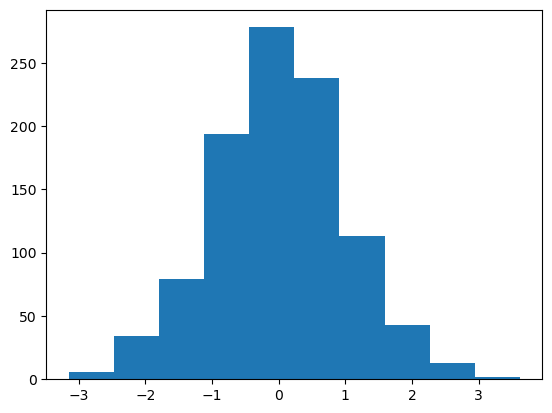

In [5]:
plt.hist(univariate_data);

In [8]:
mean = [0, 0]
cov = [[1, 0], [0, 1]]  # diagonal covariance, independent variables
multivariate_data = multivariate_normal.rvs(mean=mean, cov=cov, size=1000)

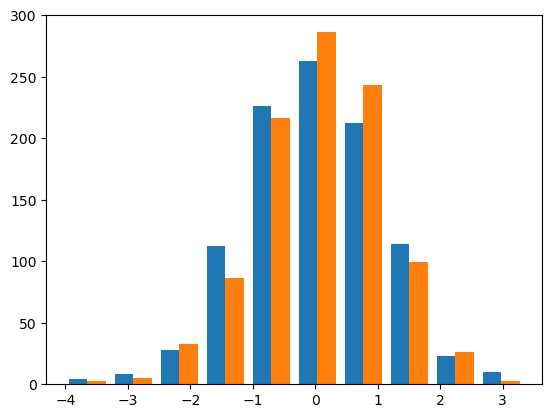

In [10]:
plt.hist(multivariate_data);

Dans le cas univarié, la distribution est définie par une moyenne et une variance : elle est symétrique autour du centre et la dispersion est la même dans toutes les directions (sur la droite).

Dans le cas multivarié :
- chaque variable a sa propre variance, donc sa propre dispersion individuelle ;
- la matrice de covariance \`cov\` contient aussi les covariances entre variables ;
- les corrélations (les éléments hors diagonal normalisés) lient les variables.

Quand les variables sont indépendantes (comme ici avec `cov = [[1, 0], [0, 1]]`), la distribution conjointe est « isotrope » et les points \`multivariate_data\` forment un nuage rond/axe-aligné. Les dimensions sont séparées : la dispersion sur la première variable ne dépend pas de la seconde.


## **Exercice 2**

La distribution de Poisson est utilisée pour modéliser le nombre d'événements qui se produisent dans un intervalle de temps ou d'espace donné lorsque ces événements surviennent de manière aléatoire et indépendante.

**Application au scénario**

Supposons qu'un magasin reçoive en moyenne 10 clients par heure. Le responsable souhaite estimer la probabilité qu'un certain nombre de clients arrivent au cours d'une heure donnée.

Dans ce contexte, la variable aléatoire X représente le nombre de clients qui entrent dans le magasin pendant une heure. Cette variable peut être modélisée par une distribution de Poisson de paramètre λ=10, où λ correspond au nombre moyen d'arrivées par intervalle de temps.

**Hypothèses de la distribution de Poisson**

Pour que cette modélisation soit pertinente, plusieurs hypothèses doivent être respectées :

Les arrivées des clients sont indépendantes : l'arrivée d'un client n'influence pas celle des autres.
Le taux moyen d'arrivée est constant pendant la période étudiée.
Les arrivées sont aléatoires et peuvent se produire à tout moment.
Deux arrivées simultanées sont très peu probables lorsque l'intervalle observé est suffisamment petit.
Utilité et implications

Cette distribution permet au gestionnaire du magasin de :

* Prévoir l'affluence à différents moments de la journée.
* Adapter le nombre de caissiers ou d'employés présents.
* Réduire les temps d'attente des clients.
* Optimiser la gestion des stocks et des ressources.

Par exemple, si la probabilité d'avoir plus de 15 clients en une heure est élevée, le responsable peut prévoir du personnel supplémentaire afin d'améliorer la qualité du service.

**Conclusion**

La distribution de Poisson est particulièrement adaptée à la modélisation des arrivées de clients dans un magasin, car elle décrit efficacement des événements aléatoires et indépendants se produisant à un rythme moyen connu. Elle constitue ainsi un outil précieux pour la planification opérationnelle et la prise de décision dans le commerce.

## **Exercice 3**

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway

# Seed for reproducibility
np.random.seed(0)
# Sales data across different regions
region1 = np.random.normal(20000, 3000, 30)  # Region 1 sales
region2 = np.random.normal(22000, 3500, 30)  # Region 2 sales
region3 = np.random.normal(25000, 5000, 30)  # Region 3 sales
sales_data = pd.DataFrame({
    'Region 1': region1,
    'Region 2': region2,
    'Region 3': region3
})

In [16]:
anov = f_oneway(region1,region2,region3)

H0 : Les ventes sont pareils dans toutes les régions  
H1 : Chaque région vend différemment

In [17]:
anov

F_onewayResult(statistic=np.float64(6.862397278587612), pvalue=np.float64(0.0017086555155734465))

pvalue < 0.05, on rejette H0, il existe une différence significative entre les prix dans chaque région

## **Exercice 4**

In [20]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Seed for reproducibility
np.random.seed(0)

# Sample data
X = np.random.rand(100) * 50  # Independent variable (e.g., hours studied)
Y = 2.5 * X + np.random.randn(100) * 10  # Dependent variable (e.g., test scores)

# Creating a DataFrame
linear_regression_data = pd.DataFrame({
  'Hours Studied': X,
  'Test Score': Y
})

In [24]:
x = linear_regression_data['Hours Studied']
y = linear_regression_data['Test Score']

In [25]:
# Performing linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# The slope and intercept of the regression line
print("Slope:", slope)
print("Intercept:", intercept)

Slope: 2.4873870042804094
Intercept: 2.22151077447225


In [26]:
r_squared = r_value ** 2

print(f"Pente (slope) : {slope:.4f}")
print(f"Ordonnée à l'origine (intercept) : {intercept:.4f}")
print(f"Coefficient de détermination (R²) : {r_squared:.4f}")



Pente (slope) : 2.4874
Ordonnée à l'origine (intercept) : 2.2215
Coefficient de détermination (R²) : 0.9283


### **Interprétation**
* Vu que la pente est positive, il existe une relation entre les heures d'étude et le score élévé au test
* L'intercept de 2.2 signifie qu'un étudiant n'ayant effectué aucune heure d'étude obtiendrait un score prédit d'environ 2,22 points.
* Le coefficient de détermination R² = 0,9283 révèle que près de 93 % de la variation des scores est expliquée par les heures d'étude, ce qui témoigne d'une excellente qualité d'ajustement du modèle de régression.